 # Метрики качества модели

Мы уже использовали некоторые метрики для оценки качества моделей, например, долю правильно классифицированных примеров для оценки качества классификации. 
Однако подобных метрик очень много и очень важно при отборе моделей и корректировке параметров подобрать
правильную метрику.

## Метрики для бинарной классификации

Давайте задумаемся, все ли ошибки модели, осуществляющей бинарную классификацию, одинаковы. Предположим, модель решает является опухоль злокачественной (+) или нет (-). Она может как ошибочно отнести здорового человека к классу больных, так и больного к классу здоровых. Какие будут последствия этих ошибок?

Если здоровый пациент будет классифицирован как больной (`ложно положительный пример`, false positive), это даст
повод для дополнительного обследования, что приведет к некоторым затратам и неудобствам для пациента (и, возможно, к определенному психическому дискомфорту). 

Другая возможная ошибка состоит в том,
что больной пациент будет классифицирован как здоровый
(`ложно отрицательный пример`, false negative), не пройдет дополнительные тесты и не получит
лечения. Недиагностированный вовремя рак может привести к
серьезным проблемам со здоровьем и может даже закончиться
смертельным исходом. 

Очевидно, что в данной задаче мы хотим минимизировать долю ложно
отрицательных примеров, тогда как ложно положительные примеры
можно считать гораздо менее значительной неприятностью.
Вообще, в любых задачах машинного обучения каждый
ложно положительный и ложно отрицательный прогноз редко приводит
к одним и тем же последствиям.

Типы ошибок играют важную роль, когда один из двух классов
встречается гораздо чаще, чем другой (`несбалансированный набор данных`). Это очень распространенная
ситуация на практике.

Представьте, что у нас количество образцов 1, 2 классов относится друг к другу как 9:1. Давайте тогда просто всегда указывать в качестве ответа 1 класс. Доля правильных ответов такого "классификатора" составит аж 90%. 
Мы можем воспользоваться `DummyClassifier`, который всегда
предсказывает мажоритарный класс, чтобы проиллюстрировать, насколько малоинформативной может быть правильность.

На основе набора данных digits создадим несбалансированный набор данных с пропорциями 9:1, создав два класса «не-девятка» и «девятка». 

In [44]:
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
digits = load_digits()

y = digits.target == 9
X_train, X_test, y_train, y_test = train_test_split(digits.data, y, random_state=0)

In [45]:
import numpy as np
from sklearn.dummy import DummyClassifier

dummy_majority = DummyClassifier(strategy='most_frequent').fit(X_train, y_train)
pred_most_frequent = dummy_majority.predict(X_test)
print("Правильность на тестовом наборе: {:.2f}".format(dummy_majority.score(X_test, y_test)))

Правильность на тестовом наборе: 0.90


У "настоящего" классификатора точность почти такая же!

In [46]:
from sklearn.tree import DecisionTreeClassifier
tree = DecisionTreeClassifier(max_depth=2).fit(X_train, y_train)
pred_tree = tree.predict(X_test)
print("Правильность на тестовом наборе: {:.2f}".format(tree.score(X_test, y_test)))

Правильность на тестовом наборе: 0.92


Логистическая регрессия дает результат получше. Прогнозы модели логистической регрессии сохраним в pred_logreg.

In [56]:
from sklearn.linear_model import LogisticRegression
logreg = LogisticRegression(C=0.1, max_iter=10000).fit(X_train, y_train)
pred_logreg = logreg.predict(X_test)
print("Правильность logreg: {:.2f}".format(logreg.score(X_test, y_test)))

Правильность logreg: 0.98


### Матрица ошибок

Одним из наиболее развернутых способов, позволяющих оценить
качество бинарной классификации, является использование `матрицы ошибок`. Давайте исследуем прогнозы модели LogisticRegression
с помощью функции confusion_matrix. 

In [57]:
from sklearn.metrics import confusion_matrix
confusion = confusion_matrix(y_test, pred_logreg)
print("Confusion matrix:\n{}".format(confusion))

Confusion matrix:
[[402   1]
 [  6  41]]


Вывод `confusion_matrix` представляет собой массив размером 2x2, где
строки соответствуют фактическим классам, а столбцы соответствуют
спрогнозированным классам. В данном случае речь идет о классах «не-
девятка» и «девятка». Число в каждой ячейке показывает количество
примеров, когда спрогнозированный класс, представленный столбцом,
совпадает или не совпадает с фактическим классом, представленным
строкой. 

Элементы главной диагонали `матрицы ошибок` соответствуют
правильным прогнозам (результатам классификации), тогда как
остальные элементы показывают, сколько примеров, относящихся к
одному классу, были ошибочно классифицированы как другой класс.

Здесь 6 девяток были распознаны, как не 9. Две не-9 напротив были классифицированы как 9.

Объявив «девятку» положительным классом, мы можем рассмотреть
элементы матрицы ошибок в терминах ложно положительных (false
positive) и ложно отрицательных (false negative) примеров. Для полноты картины мы назовем правильно
классифицированные положительные примеры истинно
положительными (`true positive`), а правильно классифицированные
отрицательные примеры – истинно отрицательными (`true negative`). Эти
термины, как правило, записывают в сокращенном виде как FP, FN, TP
и TN и приводят к следующей интерпретации матрицы ошибок:

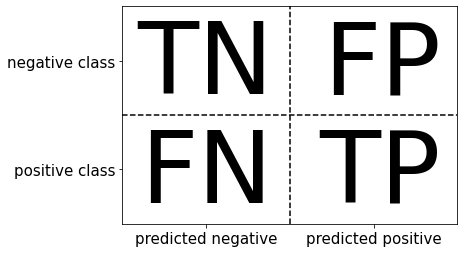

In [9]:
mglearn.plots.plot_binary_confusion_matrix()

Теперь давайте воспользуемся матрицей ошибок для сравнения ранее
построенных моделей:

In [58]:
print("Наиболее часто встречающийся класс:")
print(confusion_matrix(y_test, pred_most_frequent))
print("\nДерево решений:")
print(confusion_matrix(y_test, pred_tree))
print("\nЛогистическая регрессия")
print(confusion_matrix(y_test, pred_logreg))

Наиболее часто встречающийся класс:
[[403   0]
 [ 47   0]]

Дерево решений:
[[390  13]
 [ 24  23]]

Логистическая регрессия
[[402   1]
 [  6  41]]


Взглянув на матрицу ошибок, становится совершенно ясно, что с моделью `pred_most_frequent` что-то не так, потому что она всегда
предсказывает один и тот же класс.  Прогнозы, полученные с
помощью дерева решений, несут гораздо больше смысла, хотя правильность у этих моделей почти одинаковая. И,
наконец, мы видим, что прогнозы логистической регрессии лучше
во всех аспектах: она имеет большее количество
истинно положительных и истинно отрицательных примеров, в то время
количество ложно положительных и ложно отрицательных примеров
стало меньше. 

Из этого сравнения ясно, что лишь дерево решений и
логистическая регрессия дают разумные результаты, при этом
логистическая регрессия работает лучше дерева во всех отношениях.
Однако интерпретация матрицы ошибок немного громоздка и хотя мы
получили массу информации, анализируя все аспекты матрицы, процесс
работы с матрицей ошибок был трудоемким и сложным. Есть несколько
способов обобщить информацию, содержащуюся в матрице ошибок.

### Правильность (Accuracy)

– это количество верно классифицированных примеров (TP и TN), поделенное на общее количество примеров (суммируем все элементы матрицы ошибок).

Правильность = $\frac{TP+TN}{TP+TN+FP+FN}$

### Точность (Precision)

– это доля истинно положительных примеров от общего количества предсказанных положительных примеров.

Точность = $\frac{TP}{TP+FP}$

Показывает, сколько из предсказанных
положительных примеров оказались действительно положительными, 
используется в качестве показателя качества модели, когда
цель состоит в том, чтобы снизить количество ложно положительных
примеров. 

Например, модель предсказывает, будет ли эффективно новое разрабатываемое лекарство. Фармацевтической компании важно убедиться, что препарат действительно работает. В этом случае важно минимизировать число ложно положительных примеров (когда мы скажем, да, работает, а на самом деле нет), т.е. нужно увеличить точность.

### Полнота (Recall) 

– это доля истинно положительных
примеров от общего количества фактических положительных примеров.

Полнота = $\frac{TP}{TP+FN}$

Полнота показывает, сколько от общего
числа фактических положительных примеров было предсказано как
положительный класс, используется когда
нам необходимо определить все положительные примеры, то есть, когда
важно снизить количество ложно отрицательных примеров. 

Пример диагностики рака, приведенный ранее, является хорошей
иллюстрацией подобной задачи: важно выявить всех больных пациентов,
при этом, возможно, включив в их число здоровых пациентов. Другие
названия полноты – чувствительность (sensitivity), процент
результативный ответов или хит-рейт (hit rate) и доля истинно
положительных примеров (true positive rate, TPR).

Всегда необходимо найти компромисс между оптимизацией полноты
и оптимизацией точности. Вы легко можете получить идеальную
полноту, спрогнозировав все примеры как положительные – не будет
никаких ложно отрицательных и истинно отрицательных примеров.
Однако прогнозирование всех примеров как положительных приведет к
большому количеству ложно положительных примеров, и,
следовательно, точность будет очень низкой. 

С другой стороны,
допустим, у вас есть набор данных из 201 примера и вы строите модель,
которая прогнозирует один пример как положительный (и этот пример
действительно относится к положительному классу), а все остальные
примеры относит к отрицательному классу. Предположим, матрица
ошибок выглядит следующим образом.


\begin{array}{cc}
100 & 0 \\
100 & 1
\end{array}

Вычисляем точность и полноту. Точность будет идеальной, а полнота
– очень низкой.

Точность = $\frac{TP}{TP+FP}=\frac{1}{1+0}=1$

Полнота = $\frac{TP}{TP+FN}=\frac{1}{1+100}=0.0099$


Точность и полнота – это лишь две метрики из множества
показателей классификации, получаемых с помощью TP, FP, TN
и FN. Вы можете найти подробное описание метрик в [Википедии](https://en.wikipedia.org/wiki/Sensitivity_and_specificity)

Хотя точность и полнота являются очень важными метриками, сами
по себе они не дадут вам полной картины. Одним из способов
подытожить их является `F-мера` (F-measure), которая представляет собой гармоническое среднее точности и полноты.

### F-мера (F-measure)

F-мера=$2\cdot\frac{точность\cdotполнота}{точность+полнота}$

Давайте применим ее к прогнозам для нашего набора
данных «девятка против остальных». В данном
случае мы будем считать класс «девятка» положительным классом (он
получает метку True, тогда как класс «не-девятка» получает метку False), таким образом, положительный класс является миноритарным классом:

In [20]:
from sklearn.metrics import f1_score

print("f1-мера наибольшая частота: {:.2f}".format(f1_score(y_test, pred_most_frequent)))
print("f1-мера дерево: {:.2f}".format(f1_score(y_test, pred_tree)))
print("f1-мера логистическая регрессия: {:.2f}".format(f1_score(y_test, pred_logreg)))

f1-мера наибольшая частота: 0.00
f1-мера дерево: 0.55
f1-мера логистическая регрессия: 0.92


Похоже, что f-мера действительно дает
более лучшее представление о качестве модели, чем правильность.
Вместе с тем недостаток f-меры заключается в том, что в отличие от
правильности ее труднее интерпретировать и объяснить.
Если мы хотим получить более развернутый отчет о точности,
полноте и f1-мере, можно воспользоваться удобной функцией
`classification_report`, чтобы вычислить все три метрики сразу и
распечатать их в привлекательном виде:

In [59]:
from sklearn.metrics import classification_report

print(classification_report(y_test, pred_most_frequent, target_names=["not nine", "nine"]))

              precision    recall  f1-score   support

    not nine       0.90      1.00      0.94       403
        nine       0.00      0.00      0.00        47

    accuracy                           0.90       450
   macro avg       0.45      0.50      0.47       450
weighted avg       0.80      0.90      0.85       450



C:\anaconda3\lib\site-packages\sklearn\metrics\_classification.py:1221: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


Отметим, что мы получаем сообщение об ошибке для прогнозов модели most_frequent, поскольку не
было получено ни одного прогноза положительного класса (таким образом, знаменатель в формуле расчета f-меры равен нулю).

Функция `classification_report` печатает отчет, в котором выводятся
показатели `точности`, `полноты` и `f-меры` для отрицательного и
положительного классов. Миноритарный класс «девятка» считается
положительным классом. Значение f-меры для него равно 0. Для
мажоритарного класса «не-девятка» значение f-меры равно 0.94. Кроме
того, полнота для класса «не-девятка» равна 1, поскольку мы
классифицировали все примеры как «не-девятки». Крайний правый
столбец – это поддержка (support), которая равна фактическому
количеству примеров данного класса.

В отчете приведено и значение правильности (accuracy).
Также приводятся средние значения метрик, и средние значения
взвешенные по количеству фактических примеров в каждом классе.
Поясним процесс вычисления взвешенного среднего значения для
примере f-метрики. Сначала вычисляем веса отрицательного и
положительного классов. Вес отрицательного класса равен 403/450=0.90.
Вес положительного класса равен 47/450=0.10. Теперь
спрогнозированное значение f-меры для каждого класса умножаем на вес
соответствующего класса, складываем результаты и получаем
взвешенное среднее значение f-меры: 0.90 x 0.94 + 0.10 x 0.00 = 0.85.

Ниже
дан еще отчет для логистической
регрессии:

In [60]:
print(classification_report(y_test, pred_logreg, target_names=["not nine", "nine"]))

              precision    recall  f1-score   support

    not nine       0.99      1.00      0.99       403
        nine       0.98      0.87      0.92        47

    accuracy                           0.98       450
   macro avg       0.98      0.93      0.96       450
weighted avg       0.98      0.98      0.98       450



Проанализировав все показатели вместе, можно
составить довольно точную картину и четко увидеть превосходство
модели логистической регрессии.

## Кривые точности-полноты и ROC- кривые

### Решающая функция decision_function или predict_proba

Большинство классификаторов для оценки степени достоверности прогнозов
позволяют использовать методы `decision_function` или `predict_proba`.
Получить прогнозы можно, установив для `decision_function` или
`predict_proba` пороговое значение в некоторой фиксированной точке – в
случае бинарной классификации мы используем 0 для решающей
функции и 0.5 для метода `predict_proba`.

Ниже приведен пример несбалансированной бинарной
классификации: 400 точек данных в отрицательном классе и 50 точек
данных в положительном классе. Мы обучаем модель нелинейного SVM на этих данных, а также
выводим справа графики обучающих данных, показывающие значения
решающей функции в виде теплокарты. В самом центре графика можно
увидеть черную окружность, который соответствует пороговому значению `decision_function`, равному нулю. Точки внутри этой
окружности будут классифицироваться как положительный класс, а
точки вне окружности будут отнесены к отрицательному классу:

In [61]:
from mglearn.datasets import make_blobs
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC

X, y = make_blobs(n_samples=(400, 50), centers=2, cluster_std=[7.0, 2], random_state=22)
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=0)
svc = SVC(gamma=.05).fit(X_train, y_train)

C:\anaconda3\lib\site-packages\sklearn\utils\deprecation.py:86: FutureWarning: Function make_blobs is deprecated; Please import make_blobs directly from scikit-learn
  warnings.warn(msg, category=FutureWarning)


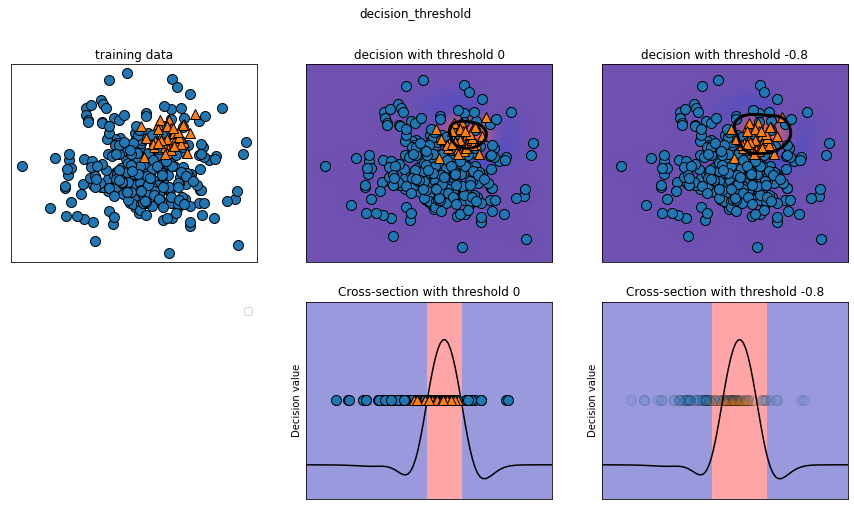

In [62]:
import mglearn
mglearn.plots.plot_decision_threshold()

Воспользуемся функцией `classification_report`, чтобы оценить
точность и полноту для обоих классов:

In [7]:
from sklearn.metrics import classification_report

print(classification_report(y_test, svc.predict(X_test)))

              precision    recall  f1-score   support

           0       0.97      0.89      0.93       104
           1       0.35      0.67      0.46         9

    accuracy                           0.88       113
   macro avg       0.66      0.78      0.70       113
weighted avg       0.92      0.88      0.89       113



Для класса 1 мы получаем довольно небольшое значение полноты и еще более низкое значение точности. Поскольку класс 0 представлен
горяздо большим количеством примеров, классификатор точнее
прогнозирует класс 0 и гораздо менее точно класс 1.

Давайте предположим, что в нашем примере гораздо важнее получить
высокое значение полноты для класса 1, как в случае со скринингом рака,
приведенном ранее. Это означает, что мы готовы допустить большее
количество ложных срабатываний (случаев, когда неверно
спрогнозирован класс 1), что даст нам большее количество истинно
положительных примеров (то есть увеличит значение полноты).

Прогнозы, полученные с помощью svc.predict, не отвечают этому
требованию, но мы можем скорректировать их, чтобы получить более
высокое значение полноты для класса 1. Для этого необходимо изменить
пороговое значение для принятия решений. По умолчанию точки данных со значениями решающей функции больше 0 будут классифицироваться
как класс 1. Мы хотим увеличить количество точек данных,
прогнозируемых как класс 1, поэтому нужно снизить пороговое значение:

In [8]:
y_pred_lower_threshold = svc.decision_function(X_test) > -0.8

Давайте взглянем на отчет о результатах классификации, полученный
для этого прогноза:

In [9]:
print(classification_report(y_test, y_pred_lower_threshold))

              precision    recall  f1-score   support

           0       1.00      0.82      0.90       104
           1       0.32      1.00      0.49         9

    accuracy                           0.83       113
   macro avg       0.66      0.91      0.69       113
weighted avg       0.95      0.83      0.87       113



Как и следовало ожидать, значение полноты для класса 1 стало
высоким, а точность упала. 

Если вам нужно увеличить точность по сравнению с полнотой или
наоборот, либо ваши данные в значительной степени не сбалансированы,
изменение порогового значения является самым простым способом
улучшить результат. 

Некоторые модели поддерживают метод
`predict_proba` вместо решающей функции `decision_function`.
Выводом `predict_proba` являются
числа, находящиеся в фиксированном диапазоне от 0 до 1 и
представляющие собой вероятности. По умолчанию порог 0.5 означает,
что если модель более чем на 50% «уверена», что данная точка является
положительным классом, точка будет классифицирована как
положительный класс. Повышение порогового значения подразумевает,
что модели требуется большая степень уверенности, чтобы принять
решение в пользу положительного класса (или меньшая степень
уверенности, чтобы принять решение в пользу отрицательного класса).

## Кривая точности-полноты

Для решаемой задачи полезно
сразу взглянуть на все возможные пороговые значения или все
возможные соотношения точности и полноты для этих пороговых
значений. Данную процедуру можно осуществить с помощью
инструмента, называемого `кривой точности-полноты` `(precision-recall
curve)`. Функцию для вычисления кривой точности-полноты можно
найти в модуле sklearn.metrics. Ей необходимо передать фактические
метки классов и спрогнозированные вероятности, вычисленные с
помощью `decision_function` или `predict_proba`:

In [10]:
from sklearn.metrics import precision_recall_curve
precision, recall, thresholds = precision_recall_curve(y_test, svc.decision_function(X_test))

Функция `precision_recall_curve` возвращает список значений
точности и полноты для всех возможных пороговых значений (всех значений решающей функции) в отсортированном виде, поэтому мы
можем построить кривую, как показано на рисунке:

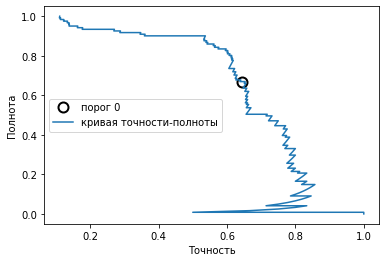

In [15]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs

# используем больший объем данных, чтобы получить более гладкую кривую
X, y = make_blobs(n_samples=(4000, 500),  cluster_std=[7.0, 2],random_state=22)

X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=0)
svc = SVC(gamma=.05).fit(X_train, y_train)

precision, recall, thresholds = precision_recall_curve(y_test, svc.decision_function(X_test))

# находим ближайший к нулю порог
close_zero = np.argmin(np.abs(thresholds))
plt.plot(precision[close_zero], recall[close_zero], 'o', markersize=10,label="порог 0", fillstyle="none", c='k', mew=2)
plt.plot(precision, recall, label="кривая точности-полноты")
plt.xlabel("Точность")
plt.ylabel("Полнота")
plt.legend(loc="best")

Каждая точка на кривой соответствует возможному
пороговому значению решающей функции. Например, видно, что мы
можем достичь полноты 0.4 при точности около 0.8. Черный кружок
отмечает точку, соответствующую порогу 0, пороговому значению по умолчанию для решающей функции. Данная точка является
компромиссом, который выбирается при вызове метода predict.
Чем ближе кривая подходит к верхнему правом углу, тем лучше
классификатор. Точка в верхнем правом углу означает высокое значение
точности и высокое значение полноты для соответствующего порога.
Кривая начинается в верхнем левом углу, что соответствует очень
низкому порогу, все примеры классифицируются как положительный
класс. Повышение порога перемещает кривую в сторону более высоких
значений точности и в то же время более низких значений полноты. При
дальнейшем повышении порога мы получаем ситуацию, в которой
большинство точек, классифицированных как положительные, являются
истинно пложительными, что приводит к очень высокой точности, но
более низкому значению полноты. Чем больше модель сохраняет высокое
значение полноты при одновременном увеличении точности, тем лучше.
Взглянув на эту кривую чуть более пристально, можно увидеть, что с
помощью построенной модели можно добиться точности в районе 0.5 при
очень высоком значении полноты. Если мы хотим получить гораздо более высокое значение точности, мы должны в значительной степени
пожертвовать полнотой. 

Различные классификаторы могут давать хорошее качество на
различных участках кривой, то есть в разных рабочих точках. Давайте
сравним модель SVM с моделью случайного леса, построенной на том же
наборе данных. `RandomForestClassifier` вместо `decision_function`
использует метод `predict_proba`. Функция `precision_recall_curve`
ожидает, что в качестве второго аргумента ей будет передана вероятность
положительного класса (класса 1), то есть rf.predict_proba(X_test)[:, 1]. В бинарной классификации пороговое значение по умолчанию для
`predict_proba` равно 0.5, поэтому отметим эту точку на кривой:

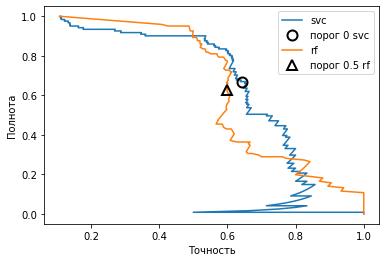

In [17]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=100, random_state=0, max_features=2)
rf.fit(X_train, y_train)

# в RandomForestClassifier есть predict_proba, но нет decision_function
precision_rf, recall_rf, thresholds_rf = precision_recall_curve(y_test, rf.predict_proba(X_test)[:, 1])
plt.plot(precision, recall, label="svc")
plt.plot(precision[close_zero], recall[close_zero], 'o', markersize=10, label="порог 0 svc", fillstyle="none", c='k', mew=2)
plt.plot(precision_rf, recall_rf, label="rf")

close_default_rf = np.argmin(np.abs(thresholds_rf - 0.5))
plt.plot(precision_rf[close_default_rf], recall_rf[close_default_rf], '^', c='k', markersize=10, label="порог 0.5 rf", fillstyle="none", mew=2)
plt.xlabel("Точность")
plt.ylabel("Полнота")
plt.legend(loc="best")

Из сравнительного графика кривых точности-полноты
для SVM и случайного леса видно, что случайный лес дает лучшее
качество, чем в SVM, для крайних пороговых значений, позволяя
получить очень высокое значение точности или очень высокое значение
полноты. Что касается центральной части кривой (соответствует
примерной точности=0.7), то SVM работает лучше. Если бы мы для
сравнения обобщающей способности в целом анализировали лишь f1-
меру, мы упустили бы из виду эти тонкости. f1-мера учитывает только
одну точку на кривой точности-полноты, точку, определяемую порогом
по умолчанию.

In [19]:
from sklearn.metrics import f1_score

print("f1-мера random forest: {:.3f}".format(
f1_score(y_test, rf.predict(X_test))))
print("f1-мера svc: {:.3f}".format(f1_score(y_test, svc.predict(X_test))))

f1-мера random forest: 0.610
f1-мера svc: 0.656


Сравнение двух кривых точности-полноты дает много детальной
информации, но представляет собой довольно трудоемкий процесс.
Чтобы выполнить автоматическое сравнение моделей мы могли бы
обобщить информацию, содержащуюся в кривой, не ограничиваясь
конкретным пороговым значением или рабочей точкой. Один из
способов подытожить информацию кривой заключается в вычислении
интеграла или площади под кривой точности-полноты, он также известен
как метод средней точности (average precision). 

Для вычисления
средней точности вы можете воспользоваться функцией
`average_precision_score`. Поскольку нам нужно вычислить ROC-
кривую и рассмотреть несколько пороговых значений, функции
`average_precision_score` вместо результата `predict` нужно передать
результат `decision_function` или `predict_proba`:

In [20]:
from sklearn.metrics import average_precision_score
ap_rf = average_precision_score(y_test, rf.predict_proba(X_test)[:, 1])
ap_svc = average_precision_score(y_test, svc.decision_function(X_test))
print("Средняя точность random forest: {:.3f}".format(ap_rf))
print("Средняя точность svc: {:.3f}".format(ap_svc))

Средняя точность random forest: 0.660
Средняя точность svc: 0.666


При усреднении по всем возможным пороговым значением мы видим,
что случайный лес и SVC дают примерно одинаковое качество модели. Это в
значительном мере отличаются от результата, полученного нами ранее с
помощью `f1_score`. Поскольку средняя точность равна площади под
кривой, которая принимает значения от 0 до 1, средняя точность всегда
возвращает значение от 0 (худшее значение) до 1 (лучшее значение).

### ROC- кривая

Еще один инструмент, который обычно используется для анализа
поведения классификаторов при различных пороговых значениях – это
receiver operating characteristics curve или кратко ROC-кривая. Как и кривая
точности-полноты, ROC-кривая позволяет рассмотреть все пороговые
значения для данного классификатора, но вместо точности и полноты
она показывает долю ложно положительных примеров (false positive rate,
FPR) в сравнении с долей истинно положительных примеров (true positive rate, TPR). 

Вспомним, что доля истинно положительных примеров –
это просто еще одно название полноты, тогда как доля ложно положительных примеров – это доля ложно положительных примеров от общего количества отрицательных примеров:

FPR=$\frac{FP}{FP+TN}$

ROC-кривую можно вычислить с помощью функции roc_curve

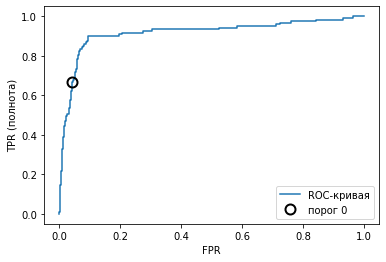

In [21]:
from sklearn.metrics import roc_curve

fpr, tpr, thresholds = roc_curve(y_test, svc.decision_function(X_test))
plt.plot(fpr, tpr, label="ROC-кривая")
plt.xlabel("FPR")
plt.ylabel("TPR (полнота)")

# находим пороговое значение, ближайшее к нулю
close_zero = np.argmin(np.abs(thresholds))
plt.plot(fpr[close_zero], tpr[close_zero], 'o', markersize=10,
label="порог 0", fillstyle="none", c='k', mew=2)
plt.legend(loc=4)

Идеальная ROC-кривая проходит через левый верхний угол,
соответствуя классификатору, который дает высокое значение полноты
при низкой доле ложно положительных примеров. Проанализировав
значения полноты и FPR для порога по умолчанию 0, мы видим, что
можем достичь гораздо более высокого значения полноты (около 0.9)
лишь при незначительном увеличении FPR. Точка, ближе всего расположенная к верхнему левому углу, возможно, будет лучшей рабочей
точкой, чем та, что выбрана по умолчанию. 

На следующем рисунке вы можете сравнить случайный лес и SVM с помощью
ROC-кривых:

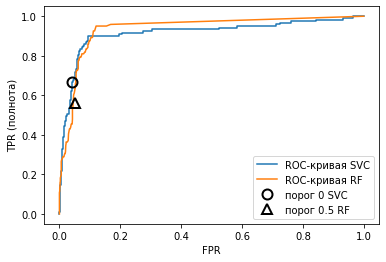

In [22]:
from sklearn.metrics import roc_curve

fpr_rf, tpr_rf, thresholds_rf = roc_curve(y_test, rf.predict_proba(X_test)[:, 1])
plt.plot(fpr, tpr, label="ROC-кривая SVC")
plt.plot(fpr_rf, tpr_rf, label="ROC-кривая RF")
plt.xlabel("FPR")
plt.ylabel("TPR (полнота)")
plt.plot(fpr[close_zero], tpr[close_zero], 'o', markersize=10,
label="порог 0 SVC", fillstyle="none", c='k', mew=2)

close_default_rf = np.argmin(np.abs(thresholds_rf - 0.5))
plt.plot(fpr_rf[close_default_rf], tpr[close_default_rf], '^', markersize=10,
label="порог 0.5 RF", fillstyle="none", c='k', mew=2)
plt.legend(loc=4)

Как и в случае с кривой точности-полноты, мы хотим подытожить
информацию ROC-кривой с помощью одного числа, площади под кривой
(обычно ее просто называют AUC, при этом имейте в виду, что речь идет
о ROC-кривой). Мы можем вычислить площадь под ROC-кривой с
помощью функции `roc_auc_score`

In [23]:
from sklearn.metrics import roc_auc_score
rf_auc = roc_auc_score(y_test, rf.predict_proba(X_test)[:, 1])
svc_auc = roc_auc_score(y_test, svc.decision_function(X_test))
print("AUC для случайного леса: {:.3f}".format(rf_auc))
print("AUC для SVC: {:.3f}".format(svc_auc))

AUC для случайного леса: 0.937
AUC для SVC: 0.916


Сравнив случайный лес и SVM с помощью AUC, мы можем сделать
вывод, что случайный лес дает чуть более лучшее качество модели, чем
SVM. 

Давайте вернемся к задаче, которую мы решали ранее, классифицируя
в наборе digits девятки и остальные цифры. Мы классифицируем
наблюдения, используя SVM с тремя различными настройками ширины
ядра и gamma 

gamma = 1.00 правильность = 0.90 AUC = 0.50
gamma = 0.07 правильность = 0.90 AUC = 0.99
gamma = 0.01 правильность = 0.90 AUC = 1.00


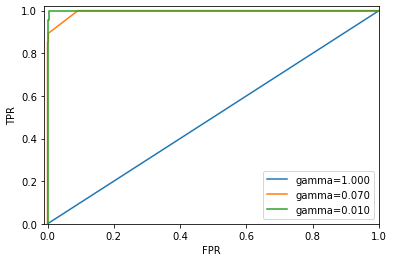

In [30]:
from sklearn.datasets import load_digits
digits = load_digits()


y = digits.target == 9

X_train, X_test, y_train, y_test = train_test_split(digits.data, y, random_state=0)
plt.figure()

for gamma in [1, 0.07, 0.01]:
    svc = SVC(gamma=gamma).fit(X_train, y_train)
    accuracy = svc.score(X_test, y_test)
    auc = roc_auc_score(y_test, svc.decision_function(X_test))
    fpr, tpr, _ = roc_curve(y_test , svc.decision_function(X_test))
    print("gamma = {:.2f} правильность = {:.2f} AUC = {:.2f}".format(gamma, accuracy, auc))
    plt.plot(fpr, tpr, label="gamma={:.3f}".format(gamma))
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.xlim(-0.01, 1)
plt.ylim(0, 1.02)
plt.legend(loc="best")

Правильность при использовании различных значений gamma остается
одинаковой и составляет 90%. Одинаковое значение правильности может
быть случайностью, а может быть нет. Однако взглянув на AUC и
соответствующую кривую, мы видим четкое различие между этими
тремя моделями. При gamma=1.0 значение AUC фактически
соответствует случайному классификатору. При gamma=0.07 качество модели резко повышается.
И, наконец, при gamma=0.01, мы получим идеальное значение AUC,
равное 1.0. 

## Метрики для мультиклассовой классификации

В основном, все
метрики для мультиклассовой классификации являются производными
от метрик классификации, но при этом усредняются по всем классам. В
мультиклассовой классификации правильность вновь определяется как
доля правильно классифицированных примеров. И опять же, когда
классы не сбалансированы, правильность перестает быть адекватной
метрикой оценки качества. Представьте себе задачу трехклассовой
классификации, когда 85% точек данных принадлежат к классу А, 10% –
к классу В и 5% – к классу C. Что означает среднее значение
правильности 85% применительно к этому набору данных? В целом
результаты мультиклассовой классификации труднее интерпретировать,
чем результаты бинарной классификации. Помимо правильности часто
используемыми инструментами являются матрица ошибок и отчет о
результатах классификации, которые мы рассматривали, разбирая
случай бинарной классификации ранее. Давайте
применим эти два метода оценки для классификации 10 различных
рукописных цифр в наборе данных digits:

In [40]:
from sklearn.metrics import accuracy_score
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix

X_train, X_test, y_train, y_test = train_test_split(digits.data, digits.target, random_state=3)
lr = LogisticRegression(max_iter=10000).fit(X_train, y_train)
pred = lr.predict(X_test)
print("Accuracy: {:.3f}".format(accuracy_score(y_test, pred)))
print("Confusion matrix:\n{}".format(confusion_matrix(y_test, pred)))

Accuracy: 0.942
Confusion matrix:
[[55  0  0  0  0  0  0  0  0  0]
 [ 0 45  0  0  0  0  0  0  2  0]
 [ 0  1 44  1  0  0  0  0  0  0]
 [ 0  0  1 46  0  0  0  0  1  0]
 [ 0  6  0  0 47  0  0  1  1  0]
 [ 0  1  0  0  1 35  0  0  0  4]
 [ 0  1  0  0  0  0 34  0  1  0]
 [ 0  0  0  0  0  0  0 49  0  0]
 [ 0  0  0  0  0  0  0  0 40  0]
 [ 0  0  0  0  0  1  0  1  2 29]]


Модель имеет точность 94.2%, что уже говорит нам об очень хорошем
качестве модели. Матрица ошибок дает нам несколько более подробную
информацию. Как и в случае бинарной классификации, каждая строка
соответствует фактической метке класса, а каждый столбец соответствует
спрогнозированной метке класса. Построим более наглядный
график:

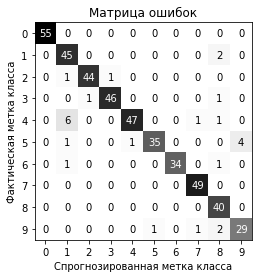

In [41]:
scores_image = mglearn.tools.heatmap(
    confusion_matrix(y_test, pred), xlabel='Спрогнозированная метка класса',
    ylabel='Фактическая метка класса', xticklabels=digits.target_names,
    yticklabels=digits.target_names, cmap=plt.cm.gray_r, fmt="%d")
plt.title("Матрица ошибок")
plt.gca().invert_yaxis()

Фактическое количество примеров, относящихся к первому классу
(цифре 0), равно 55 и все эти примеры были классифицированы как
 0 (то есть ложно отрицательные примеры для класса 0
отсутствуют). Об этом говорит тот факт, что все остальные элементы
первой строки матрицы ошибок имеют нулевые значения. Кроме того, ни
одна из остальных цифр не была ошибочно классифицирована как 0,
поскольку все остальные элементы первого столбца имеют нулевые
значения (то есть ложно положительные примеры для класса 0
отсутствуют). Однако некоторые цифры были спутаны с остальными,
например, цифра 2 (третья строка), два раза была классифицирована как 1 и 3. 

С помощью функции `classification_report` мы можем вычислить
точность, полноту и f-меру для каждого класса:

In [42]:
print(classification_report(y_test, pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        55
           1       0.83      0.96      0.89        47
           2       0.98      0.96      0.97        46
           3       0.98      0.96      0.97        48
           4       0.98      0.85      0.91        55
           5       0.97      0.85      0.91        41
           6       1.00      0.94      0.97        36
           7       0.96      1.00      0.98        49
           8       0.85      1.00      0.92        40
           9       0.88      0.88      0.88        33

    accuracy                           0.94       450
   macro avg       0.94      0.94      0.94       450
weighted avg       0.95      0.94      0.94       450



Неудивительно, что для класса 0 получены идеальные значения
точности и полноты, равные 1, поскольку все примеры
классифицированы правильно. Для класса 6 получена идеальная
точность, поскольку отсутствуют ложно положительные примеры (ни
один из остальных классов не был ошибочно классифицирован как класс
6), тогда как для класса 7 получена идеальная полнота, поскольку
отсутствуют ложно отрицательные примеры. 